<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026
</div>

# Atmosphere Analysis 2 — Differential Flux with Honda Tables

**Description:** Uses the Honda/HKKM tables through the tpeanuts `external.honda` API to produce the height-differential atmospheric neutrino source flux $\Phi(E,h;\theta) = \Phi(E;\theta) \times f(h|E,\theta)$ used as the upper boundary condition for atmosphere-neutrino propagation.

**Physics:** Honda/HKKM integrated flux tables · production-height quantiles · height-differential source flux $\Phi(E,h)$



| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: 0.1 Honda/HKKM tables, 0.2 integrated flux $\Phi(E,\cos\theta)$, 0.3 production-height quantiles, 0.4 differential flux $\Phi(E,h;\theta)$, 0.5 PDF reconstruction |
| [1](#1.-Libraries) | **Libraries**: imports and configuration |
| [2](#2.-Honda-Table-Structure) | **Honda Table Structure**: 2.1 file catalogue, 2.2 table selection |
| [3](#3.-Single-Direction-Differential-Flux) | **Single-Direction Differential Flux**: 3.1 integrated $\Phi(E;\theta)$, 3.2 height PDF $f(h|E)$, 3.3 $\Phi(E,h)$ heatmap |
| [4](#4.-Angular-Dependence) | **Angular Dependence**: 4.1 multi-angle grid, 4.2 angular profiles |
| [5](#5.-Production-Height-Statistics) | **Production Height Statistics**: 5.1 median height, 5.2 height PDF heatmap |
| [6](#6.-Particle-and-Flavour-Comparison) | **Particle Comparison**: 6.1 $\nu_e$ vs $\nu_\mu$ spectra, 6.2 $\nu/\bar\nu$ ratios |
| [7](#7.-Solar-and-Mountain-Corrections) | **Solar and Mountain Corrections**: 7.1 solar min vs max, 7.2 mountain effect |
| [8](#8.-Flux-Normalization-Check) | **Flux Normalization**: 8.1 integrate $f(h|E)\,\mathrm{d}h$ |
| [9](#9.-Summary) | **Summary** |

## 0. Theory Background

---

### 0.1 The Honda/HKKM Atmospheric Neutrino Flux Tables

The **Honda/HKKM tables** (Honda, Kajita, Kasahara, Midorikawa) are the standard
reference dataset for the atmospheric neutrino flux at underground detectors. They
are computed with a full 3-D Monte Carlo simulation of cosmic-ray air showers,
tracking the production and decay of pions, kaons, and muons through the atmosphere
to predict the neutrino flux at the detector. Tables are published for a set of
experimental sites (Frejus, Gran Sasso, Super-Kamiokande, INO, ORCA/ARCA, ...),
with variants for season averaging (all-year, summer, winter), solar activity level
(solar minimum / solar maximum), and the possible presence of a nearby mountain.

The data files are plain-text tables compressed as ``.d.gz`` gzip archives. Two
families of files are distributed per site:

| File family | Filename pattern | Content |
|-------------|-----------------|---------|
| Flux tables | `frj-ally-20-01-solmin.d.gz` | $\Phi(E,\cos\theta)$ per flavour |
| Height tables | `frj-ally-aa-numu.d.gz` | Production-height quantiles per flavour |

**References:**
- M. Honda, T. Kajita, K. Kasahara, S. Midorikawa, T. Sanuki,
  *Calculation of atmospheric neutrino flux using the interaction model calibrated
  with atmospheric muon data*, Phys. Rev. D **75**, 043006 (2007).
- M. Honda, M. A. Athar, T. Kajita, K. Kasahara, S. Midorikawa,
  *Atmospheric neutrino flux calculation using the NRLMSISE-00 atmospheric model*,
  Phys. Rev. D **92**, 023004 (2015).

**Web:** [http://www.icrr.u-tokyo.ac.jp/~mhonda/](http://www.icrr.u-tokyo.ac.jp/~mhonda/)

---

### 0.2 Height-Integrated Flux $\Phi(E,\cos\theta)$

Each **flux table** contains the differential neutrino flux at the detector,
integrated over all production heights and averaged over azimuth (in the
azimuth-averaged variant). The file is organised in blocks, one per
$\cos\theta$ bin:

```
average flux in [cosZ = 0.90 -- 1.00, phi_Az = 0.00 -- 360.00]
Enu(GeV)     NuMu      NuMubar    NuE       NuEbar
1.000E-01   1.054E+00  9.682E-01  5.424E-01  4.949E-01
1.259E-01   7.700E-01  7.087E-01  3.958E-01  3.622E-01
...
```

- **20 zenith bins** with centres $\cos\theta = 0.95, 0.85, \ldots, -0.95$
  ($\theta = 0^\circ$ is straight down, $\theta = 180^\circ$ straight up).
- **~50 energy rows** log-spaced from 0.1 GeV to $10^4$ GeV.
- **Four flavour columns:** $\nu_\mu$, $\bar\nu_\mu$, $\nu_e$, $\bar\nu_e$.
- **Units:** $(\mathrm{m}^2\,\mathrm{s}\,\mathrm{sr}\,\mathrm{GeV})^{-1}$
  (tpeanuts converts to $\mathrm{cm}^{-2}$ by dividing by $10^4$).

The height-integrated flux is related to the height-differential flux by:

$$\Phi(E;\,\cos\theta) \;=\; \int_0^{h_{\rm top}} \Phi(E,\,h;\,\theta)\,\mathrm{d}h$$

where $h_{\rm top} \sim 120$ km is the top of the relevant atmosphere column.

---

### 0.3 Production-Height Quantile Tables

The **production-height tables** encode the statistical distribution of the
altitude $h$ at which the parent meson or muon decayed to produce the detected
neutrino. They are stored as **quantiles** of this distribution, not as
a continuous PDF.

For each $(E, \cos\theta)$ bin, the file gives the altitudes
$h_{10\%},\, h_{20\%},\,\ldots,\, h_{90\%}$ (in metres) such that a fraction
$p$ of the neutrinos arriving with energy $E$ from direction $\cos\theta$ were
produced below altitude $h_p$:

$$F(h_p\,|\,E,\cos\theta) \;\equiv\; \Pr[h_{\rm prod} \le h_p] \;=\; p$$

Separate files are provided per neutrino flavour
($\nu_\mu$, $\bar\nu_\mu$, $\nu_e$, $\bar\nu_e$).
A typical block header looks like:

```
1  1  5  1   0.10  0.20  0.30  0.40  0.50  0.60  0.70  0.80  0.90
1.000E-01   8400.  10600.  12300.  13800.  15200.  16700.  18400.  20600.  24300.
...
```

where the header tokens are (site, flavour, zenith-bin, azimuth-bin, probabilities)
and each data row is $E_{\nu}$ [GeV] followed by the nine altitude quantiles [m].

---

### 0.4 Height-Differential Flux $\Phi(E, h;\, \theta)$

The **height-differential flux** is the quantity that tpeanuts uses as the upper
boundary condition for atmospheric neutrino propagation. It represents the
neutrino source rate per unit altitude interval:

$$\boxed{\Phi(E,\,h;\,\theta) \;=\; \Phi(E;\,\theta) \;\times\; f(h\,|\,E,\,\theta)}$$

where $f(h\,|\,E,\,\theta)$ is the **production-height probability density**,
normalised so that

$$\int_0^{h_{\rm top}} f(h\,|\,E,\,\theta)\,\mathrm{d}h \;=\; 1.$$

By construction, integrating $\Phi(E,h;\theta)$ over $h$ recovers the original
Honda integrated flux $\Phi(E;\theta)$.
The units of $\Phi(E,h;\theta)$ are
$(\mathrm{cm}^2\,\mathrm{s}\,\mathrm{sr}\,\mathrm{GeV}\,\mathrm{km})^{-1}$.

---

### 0.5 Reconstruction of $f(h\,|\,E,\,\theta)$ from Quantiles

Since the Honda tables provide $f$ only through its quantiles, tpeanuts
reconstructs the PDF from the quantile data via numerical differentiation of the
empirical CDF:

1. **Build anchor points:** prepend $(h=0,\;F=0)$ and append $(h=h_{\rm top},\;F=1)$
   to the Honda quantile pairs $\{(h_{10\%}, 0.10),\,(h_{20\%}, 0.20),\,\ldots\}$.
2. **Interpolate the CDF** piecewise-linearly between nodes onto the output height
   grid $\{h_k\}$ (default: 501 points from 0 to 120 km).
3. **Differentiate numerically:** $f(h_k) = \mathrm{d}F/\mathrm{d}h\,|_{h_k}$
   using central differences; clip negative values to zero.
4. **Renormalise:** $f \leftarrow f\,/\,\int f\,\mathrm{d}h$
   to enforce exact unit normalisation on the discrete grid.

This reconstruction recovers the integrated flux to better than $10^{-3}$
relative error for all $(E,\theta)$ bins (see Section 8 for the numerical check).

---

**References**
- M. Honda, T. Kajita, K. Kasahara, S. Midorikawa,
  *New calculation of the atmospheric neutrino flux in a three-dimensional scheme*,
  Phys. Rev. D **70**, 043008 (2004).
- M. Honda, T. Kajita, K. Kasahara, S. Midorikawa, T. Sanuki,
  *Calculation of atmospheric neutrino flux using the interaction model calibrated
  with atmospheric muon data*, Phys. Rev. D **75**, 043006 (2007).
- M. Honda, M. A. Athar, T. Kajita, K. Kasahara, S. Midorikawa,
  *Atmospheric neutrino flux calculation using the NRLMSISE-00 atmospheric model*,
  Phys. Rev. D **92**, 023004 (2015).

## 1. Libraries

Imports and notebook configuration.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show
from tpeanuts.external.honda import (
    generate_flux_for_particle_angle,
    generate_flux_for_particles_angle_grid,
    HondaTableSelection,
    find_honda_data_dir,
    honda_cosz_centers,
)
from tpeanuts.external.honda.tables import (
    choose_flux_file,
    choose_height_file,
    classify_table_name,
)

In [2]:
config     = load_notebook_config()
OUTPUT_DIR = config.output_dir("analysis", "atmosphere",'honda_analysis')
HONDA_DIR = config.output_dir("external", "honda")
SHOW_PLOTS = config.show_plots
print(f"Output directory : {HONDA_DIR}")
print(f"Honda directory  : {OUTPUT_DIR}")
print(f"Device           : {config.device}")

Output directory : v:\output\external\honda
Honda directory  : v:\output\analysis\atmosphere\honda_analysis
Device           : cpu


## 2. Honda Table Structure

Honda/HKKM tables are plain-text (gzip-compressed) ``.d.gz`` files distributed per experimental site. Each filename encodes the site code, season, solar activity, angular binning mode, and (for height files) neutrino flavour. The tpeanuts function `find_honda_data_dir()` locates the local copy of these files and `classify_table_name()` decodes each filename into its metadata.

### 2.1 File Catalogue

The first step is to locate the Honda data directory and inspect which table variants are available.

In [3]:
honda_dir = find_honda_data_dir(path = HONDA_DIR)
files = sorted(honda_dir.glob("*.d.gz"))
print(f"Honda data directory: {honda_dir}")
print(f"Found {len(files)} table files:")
print()
fmt = "  {:<48s}  {:<20s}  {}"
print(fmt.format("Filename", "Table type", "Angular mode / flavour"))
print("  " + "-" * 90)
MAX_FILES = 20
for ix, f in enumerate(files):
    if MAX_FILES is not None:
        if ix > MAX_FILES:
            print(f'\n\t... only the {MAX_FILES} first files are listed')
            break
    meta = classify_table_name(f.name)
    ttype = meta.get("table_type", "?")
    detail = meta.get("angular_mode", meta.get("flavour", ""))
    solar  = meta.get("solar", "")
    mtn    = " [mtn]" if meta.get("mountain") else ""
    suffix = f"{solar}{mtn}" if solar else ""
    print(fmt.format(f.name, ttype, f"{detail}  {suffix}".strip()))

Honda data directory: v:\output\external\honda
Found 588 table files:

  Filename                                          Table type            Angular mode / flavour
  ------------------------------------------------------------------------------------------
  frj-0305-01-01-solmax.d.gz                        flux                  all-direction-averaged  solmax
  frj-0305-01-01-solmin.d.gz                        flux                  all-direction-averaged  solmin
  frj-0305-20-01-mtn-solmax.d.gz                    flux                  azimuth-averaged  solmax [mtn]
  frj-0305-20-01-mtn-solmin.d.gz                    flux                  azimuth-averaged  solmin [mtn]
  frj-0305-20-01-solmax.d.gz                        flux                  azimuth-averaged  solmax
  frj-0305-20-01-solmin.d.gz                        flux                  azimuth-averaged  solmin
  frj-0305-20-12-mtn-solmax.d.gz                    flux                  zenith+azimuth  solmax [mtn]
  frj-0305-20-12-m

### 2.2 Table Selection

`HondaTableSelection` is a frozen dataclass that selects one table variant by site, season, solar activity, mountain flag, and angular mode. The defaults match the Frejus (FNAL/Daya Bay equivalent) all-year azimuth-averaged solar-minimum flux.

| Parameter | Meaning | Example values |
|-----------|---------|---------------|
| `site_code` | Three-letter Honda site identifier | `"frj"` (Frejus), `"grn"` (Gran Sasso), `"sk"` (Super-K) |
| `season_code` | Season-averaging token | `"ally"` (all-year), `"summ"`, `"wint"` |
| `solar` | Solar modulation level | `"solmin"`, `"solmax"` |
| `mountain` | Include nearby mountain shadow | `True` / `False` |
| `angular_mode` | Zenith/azimuth binning | `"azimuth-averaged"`, `"zenith+azimuth"` |

**Expected results:** 
- The selected flux file and per-flavour height files are listed.

In [4]:
sel = HondaTableSelection(
    site_code    = "frj",
    season_code  = "ally",
    solar        = "solmin",
    mountain     = False,
    angular_mode = "azimuth-averaged",
)

flux_file = choose_flux_file(honda_dir, sel)
print(f"Selected flux file : {flux_file.name}")
print(f"Selection          : {sel}")
print()
print("Height files by particle:")
for particle in ["nue", "antinue", "numu", "antinumu"]:
    hf = choose_height_file(honda_dir, sel, particle)
    print(f"  {particle:10s}: {hf.name if hf else 'not found'}")

Selected flux file : frj-ally-20-01-solmin.d.gz
Selection          : HondaTableSelection(site_code='frj', season_code='ally', solar='solmin', mountain=False, angular_mode='azimuth-averaged', azimuth_averaged_height=True)

Height files by particle:
  nue       : frj-ally-aa-nue.d.gz
  antinue   : frj-ally-aa-nuebar.d.gz
  numu      : frj-ally-aa-numu.d.gz
  antinumu  : frj-ally-aa-numubar.d.gz


## 3. Single-Direction Differential Flux

`generate_flux_for_particle_angle()` produces the full height-differential source flux for one particle at one zenith angle. It:
1. Interpolates the Honda integrated flux $\Phi(E; X_{\rm obs})$ onto the requested energy grid (log-linear in $E$, linear in $\cos\theta$).
2. Reconstructs the production-height PDF $f(h|E,\theta)$ from the Honda quantile tables as $d{\rm CDF}/dh$, normalized so $\int f(h|E,\theta)\,dh = 1$.
3. Returns the product $\Phi(E,h) = \Phi(E; X_{\rm obs}) \times f(h|E,\theta)$.

In [5]:
THETA_DEG = 30.0     # zenith angle in degrees (0 = straight down, 90 = horizontal)
PARTICLE  = "numu"   # Honda-supported particles: nue, antinue, numu, antinumu

result = generate_flux_for_particle_angle(
    PARTICLE,
    theta_deg = THETA_DEG,
    selection = sel,
    honda_data_dir = HONDA_DIR,
    save      = False,
)

E_GeV  = result["E_grid_GeV"].cpu().numpy()   # (nE,)  energy grid in GeV
h_km   = result["h_grid_km"].cpu().numpy()    # (nh,)  height grid in km
phi_E  = result["phi_E_obs"].cpu().numpy()    # (nE,)  height-integrated flux  [cm^-2 s^-1 sr^-1 GeV^-1]
f_Eh   = result["f_Eh"].cpu().numpy()         # (nE, nh)  height density  [km^-1]
phi_Eh = result["phi_Eh"].cpu().numpy()       # (nE, nh)  Phi(E,h)  [cm^-2 s^-1 sr^-1 GeV^-1 km^-1]

print(f"Energy grid : {E_GeV.size} points, {E_GeV[0]:.3f} -- {E_GeV[-1]:.0f} GeV")
print(f"Height grid : {h_km.size} points, {h_km[0]:.0f} -- {h_km[-1]:.0f} km")
print(f"phi_E shape : {phi_E.shape}")
print(f"f_Eh  shape : {f_Eh.shape}")
print(f"phi_Eh shape: {phi_Eh.shape}")

Energy grid : 101 points, 0.100 -- 10000 GeV
Height grid : 501 points, 0 -- 120 km
phi_E shape : (101,)
f_Eh  shape : (101, 501)
phi_Eh shape: (101, 501)


### 3.1 Height-Integrated Energy Spectrum $\Phi(E; \theta)$

$\Phi(E; \theta)$ is the total (height-integrated) flux at the detector for a fixed zenith direction $\theta$. It is the quantity published directly in Honda tables.

**Expected results:** 
- A steeply falling spectrum from $\sim 10$ GeV (cm² s sr GeV)⁻¹ at 0.1 GeV to $\sim 10^{-9}$ at 100 GeV. The $E^2$-weighted version reveals the spectral shape more clearly.

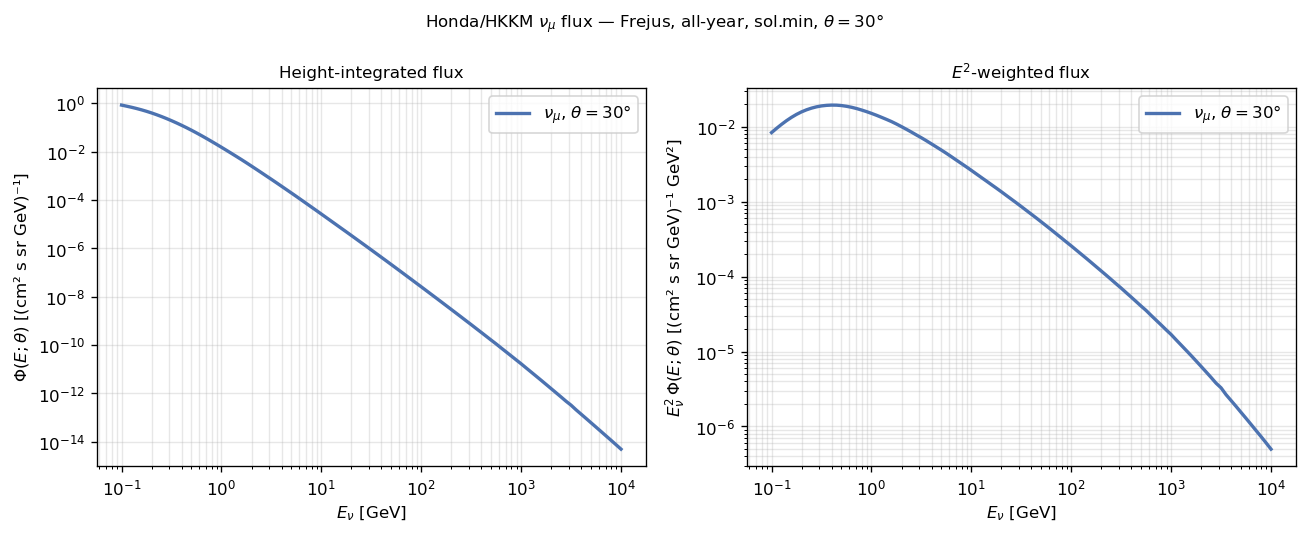

v:\output\analysis\atmosphere\honda_analysis\atm2_fig21_phi_E.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: absolute flux
ax = axes[0]
ax.loglog(E_GeV, phi_E, color="#4c72b0", lw=2,
          label=rf"$\nu_\mu$, $\theta={THETA_DEG:.0f}°$")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\Phi(E; \theta)$ [(cm² s sr GeV)⁻¹]")
ax.set_title("Height-integrated flux", fontsize=10)
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# Right: E^2-weighted flux
ax = axes[1]
ax.loglog(E_GeV, phi_E * E_GeV**2, color="#4c72b0", lw=2,
          label=rf"$\nu_\mu$, $\theta={THETA_DEG:.0f}°$")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E_\nu^2\,\Phi(E; \theta)$ [(cm² s sr GeV)⁻¹ GeV²]")
ax.set_title(r"$E^2$-weighted flux", fontsize=10)
ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.suptitle(
    rf"Honda/HKKM $\nu_\mu$ flux — Frejus, all-year, sol.min, $\theta={THETA_DEG:.0f}°$",
    fontsize=10,
)
fig.tight_layout()
save_and_show("atm2_fig21_phi_E.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.2 Production Height PDF $f(h|E, \theta)$

The production-height PDF $f(h|E,\theta)$ encodes where in the atmosphere the parent mesons and muons decayed to produce the observed neutrinos. It is reconstructed from the Honda quantile data (10%, 20%, ..., 90% height quantiles) as the numerical derivative of the piecewise-linear CDF.

- At **low energy** ($E_\nu \lesssim 0.3$ GeV) pion decays dominate: production is spread over a wide height range, typically peaking around 15–25 km.
- At **high energy** ($E_\nu \gtrsim 3$ GeV) muon decays become important and the distribution shifts to lower altitudes (10–20 km) and narrows.

**Expected results:**
- Broad peaks at 10–25 km shifting downward with increasing energy.

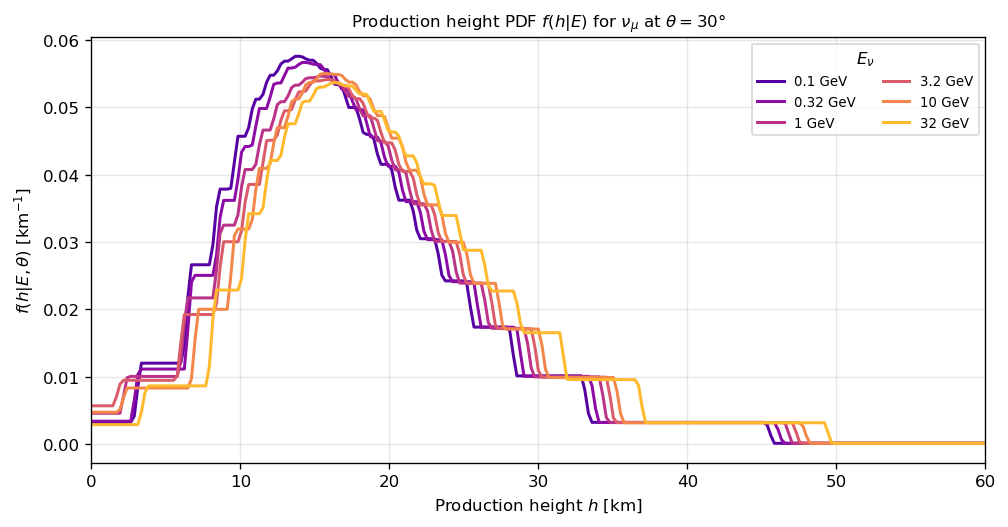

v:\output\analysis\atmosphere\honda_analysis\atm2_fig22_fEh.png


In [7]:
E_show  = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]   # GeV
colors  = plt.cm.plasma(np.linspace(0.15, 0.85, len(E_show)))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for e_tgt, col in zip(E_show, colors):
    ie = np.argmin(np.abs(E_GeV - e_tgt))
    ax.plot(h_km, f_Eh[ie], color=col, lw=1.8, label=f"{E_GeV[ie]:.2g} GeV")

ax.set_xlabel("Production height $h$ [km]")
ax.set_ylabel(r"$f(h|E,\theta)$ [km$^{-1}$]")
ax.set_title(
    rf"Production height PDF $f(h|E)$ for $\nu_\mu$ at $\theta={THETA_DEG:.0f}°$",
    fontsize=10,
)
ax.set_xlim(0, 60)
ax.legend(title=r"$E_\nu$", ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show("atm2_fig22_fEh.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.3 Height-Differential Flux $\Phi(E, h)$

The height-differential source flux $\Phi(E,h) = \Phi(E; X_{\rm obs}) \times f(h|E,\theta)$ is the quantity that tpeanuts uses as the upper boundary condition for the neutrino transport equation. Its shape $(n_E, n_h)$ gives the neutrino source as a function of both energy and production altitude.

**Expected results:** 
- A 2D field concentrated between 10–30 km at low energies and shifting toward lower altitudes with energy, with overall magnitude following the steeply falling Honda energy spectrum.

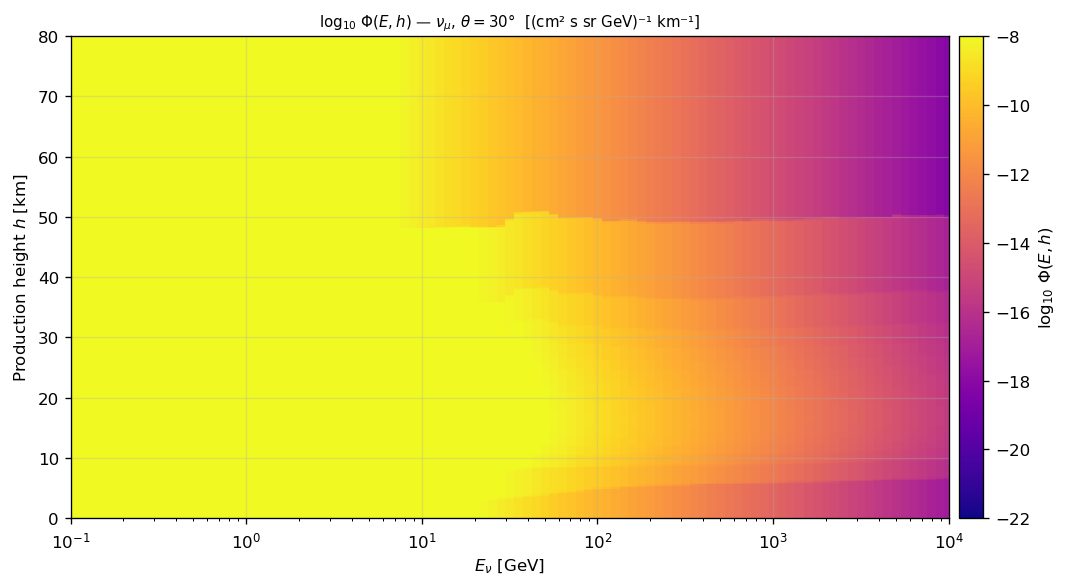

v:\output\analysis\atmosphere\honda_analysis\atm2_fig23_phi_Eh.png


In [8]:
# log10 of phi_Eh for visualization; mask zeros
with np.errstate(divide="ignore"):
    log_phi = np.where(phi_Eh > 0, np.log10(phi_Eh), np.nan)

fig, ax = plt.subplots(figsize=(9.5, 5.0))
E_mesh  = np.concatenate([[E_GeV[0] * 0.9], 0.5 * (E_GeV[:-1] + E_GeV[1:]),
                           [E_GeV[-1] * 1.1]])
h_mesh  = np.concatenate([[0.0], 0.5 * (h_km[:-1] + h_km[1:]),
                           [h_km[-1] + (h_km[-1] - h_km[-2])]])
im = ax.pcolormesh(E_mesh, h_mesh, log_phi.T, cmap="plasma",
                   shading="flat", vmin=-22, vmax=-8)
ax.set_xscale("log")
ax.set_xlim(E_GeV[0], E_GeV[-1])
ax.set_ylim(0, 80)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel("Production height $h$ [km]")
ax.set_title(
    rf"$\log_{{10}}\,\Phi(E,h)$ — $\nu_\mu$, $\theta={THETA_DEG:.0f}°$"
    r"  [(cm² s sr GeV)⁻¹ km⁻¹]",
    fontsize=9,
)
plt.colorbar(im, ax=ax, label=r"$\log_{{10}}\,\Phi(E,h)$", pad=0.01)
fig.tight_layout()
save_and_show("atm2_fig23_phi_Eh.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 4. Angular Dependence

The Honda tables cover 20 zenith bins in $\cos\theta \in [-0.95, 0.95]$ with step 0.10. The height-differential flux varies substantially with zenith angle because:
- **Downward-going** ($\cos\theta \approx 1$, $\theta \approx 0°$): short path length through the atmosphere, higher production heights, lower flux at multi-GeV energies.
- **Horizontal** ($\theta \approx 90°$, $\cos\theta \approx 0$): long atmospheric path, broad height distribution, enhanced multi-GeV flux from pion decay.

The standard Honda 20-bin cosθ grid is returned by `honda_cosz_centers()`.

### 4.1 Generate Multi-Angle Grid

`generate_flux_for_particles_angle_grid()` builds the flux over a grid of angles and particle types in one call, sharing the loaded Honda tables internally for efficiency.

In [9]:
cosz_centers = honda_cosz_centers()  # 20 standard Honda bins: 0.95 down to -0.95
print(f"Honda 20-bin cosZ centers: {cosz_centers}")

THETA_GRID = np.array([0., 15., 30., 45., 60., 75., 85.])   # degrees (subset)
PARTICLES  = ["numu", "nue", "antinumu", "antinue"]

grid = generate_flux_for_particles_angle_grid(
    honda_data_dir = HONDA_DIR,
    particles      = PARTICLES,
    theta_grid_deg = THETA_GRID,
    selection      = sel,
    save           = False,
)

print(f"Generated flux for {len(PARTICLES)} particles x {len(THETA_GRID)} angles.")
for flav, gdata in grid.items():
    theta_keys = sorted(gdata["results"].keys())
    print(f"  {flav:10s}: theta = {[f'{t:.0f}' for t in theta_keys]}")

Honda 20-bin cosZ centers: [ 0.95  0.85  0.75  0.65  0.55  0.45  0.35  0.25  0.15  0.05 -0.05 -0.15 -0.25 -0.35 -0.45 -0.55 -0.65 -0.75 -0.85 -0.95]
Generated flux for 4 particles x 7 angles.
  numu      : theta = ['0', '15', '30', '45', '60', '75', '85']
  nue       : theta = ['0', '15', '30', '45', '60', '75', '85']
  antinumu  : theta = ['0', '15', '30', '45', '60', '75', '85']
  antinue   : theta = ['0', '15', '30', '45', '60', '75', '85']


### 4.2 Angular Profile of $\Phi(E; \theta)$

The height-integrated $\nu_\mu$ flux as a function of energy for several zenith angles, and the angular profile at a fixed reference energy.

**Expected results:** 
- The horizontal direction ($\theta = 85°$) is enhanced by a factor $\sim 2\text{–}3$ relative to the vertical ($\theta = 0°$) at energies above $\sim 1$ GeV.

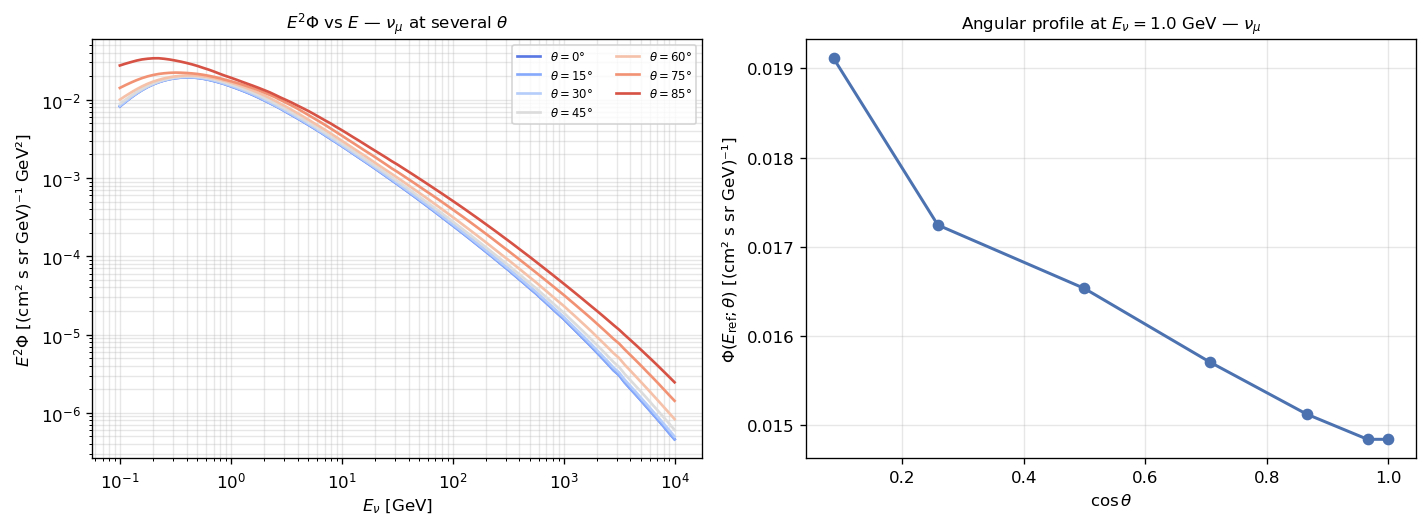

v:\output\analysis\atmosphere\honda_analysis\atm2_fig32_angular.png


In [10]:
E_ref  = 1.0   # GeV reference energy for the angular plot
colors_t = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(THETA_GRID)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: energy spectra at different theta
ax = axes[0]
for theta, col in zip(THETA_GRID, colors_t):
    r   = grid["numu"]["results"][float(theta)]
    E   = r["E_grid_GeV"].cpu().numpy()
    phi = r["phi_E_obs"].cpu().numpy()
    ax.loglog(E, phi * E**2, color=col, lw=1.6, label=rf"$\theta={theta:.0f}°$")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E^2 \Phi$ [(cm² s sr GeV)⁻¹ GeV²]")
ax.set_title(r"$E^2\Phi$ vs $E$ — $\nu_\mu$ at several $\theta$", fontsize=10)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, which="both", alpha=0.3)

# Right: angular profile at E_ref
ax = axes[1]
phi_at_E = []
for theta in THETA_GRID:
    r    = grid["numu"]["results"][float(theta)]
    E    = r["E_grid_GeV"].cpu().numpy()
    phi  = r["phi_E_obs"].cpu().numpy()
    ie   = np.argmin(np.abs(E - E_ref))
    phi_at_E.append(phi[ie])

cosz_grid = np.cos(np.deg2rad(THETA_GRID))
ax.plot(cosz_grid, phi_at_E, "o-", color="#4c72b0", lw=1.8, ms=6)
ax.set_xlabel(r"$\cos\theta$")
ax.set_ylabel(r"$\Phi(E_{\rm ref}; \theta)$ [(cm² s sr GeV)⁻¹]")
ax.set_title(rf"Angular profile at $E_\nu = {E_ref}$ GeV — $\nu_\mu$", fontsize=10)
ax.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show("atm2_fig32_angular.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 5. Production Height Statistics

Summarising $f(h|E,\theta)$ through its median and interquartile range gives compact information about how the production-height distribution shifts with energy and angle.

### 5.1 Median Production Height vs Energy

The median height $\tilde h(E, \theta)$ is where the CDF of $f(h|E,\theta)$ equals 0.5. A higher median means neutrinos are produced higher in the atmosphere (lower atmospheric density, fewer hadronic interactions).

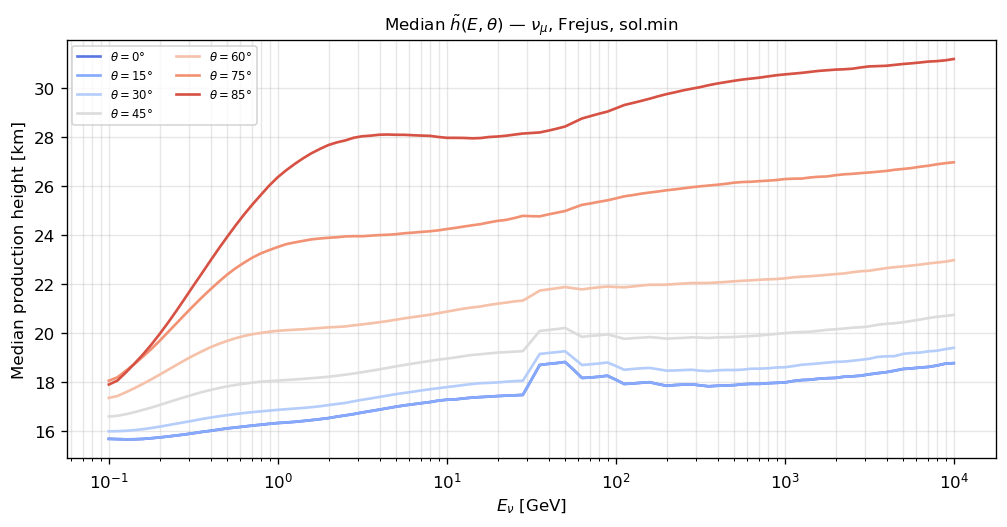

v:\output\analysis\atmosphere\honda_analysis\atm2_fig41_median_h.png


In [11]:
def median_height(f_Eh_arr, h_km_arr):
    cdf    = np.cumsum(f_Eh_arr * np.gradient(h_km_arr), axis=1)
    cdf   /= cdf[:, -1:].clip(1e-30)
    h_med  = np.array([np.interp(0.5, cdf[ie], h_km_arr) for ie in range(cdf.shape[0])])
    return h_med

colors_t = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(THETA_GRID)))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for theta, col in zip(THETA_GRID, colors_t):
    r      = grid["numu"]["results"][float(theta)]
    E      = r["E_grid_GeV"].cpu().numpy()
    f      = r["f_Eh"].cpu().numpy()
    h      = r["h_grid_km"].cpu().numpy()
    h_med  = median_height(f, h)
    ax.semilogx(E, h_med, color=col, lw=1.6, label=rf"$\theta={theta:.0f}°$")

ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel("Median production height [km]")
ax.set_title(r"Median $\tilde h(E,\theta)$ — $\nu_\mu$, Frejus, sol.min", fontsize=10)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
save_and_show("atm2_fig41_median_h.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 5.2 Height PDF Heatmap vs Zenith Angle

A 2D heatmap of $f(h|E_0, \theta)$ as a function of $\theta$ and $h$ at a fixed reference energy $E_0$ reveals how the production-height distribution broadens toward horizontal directions.

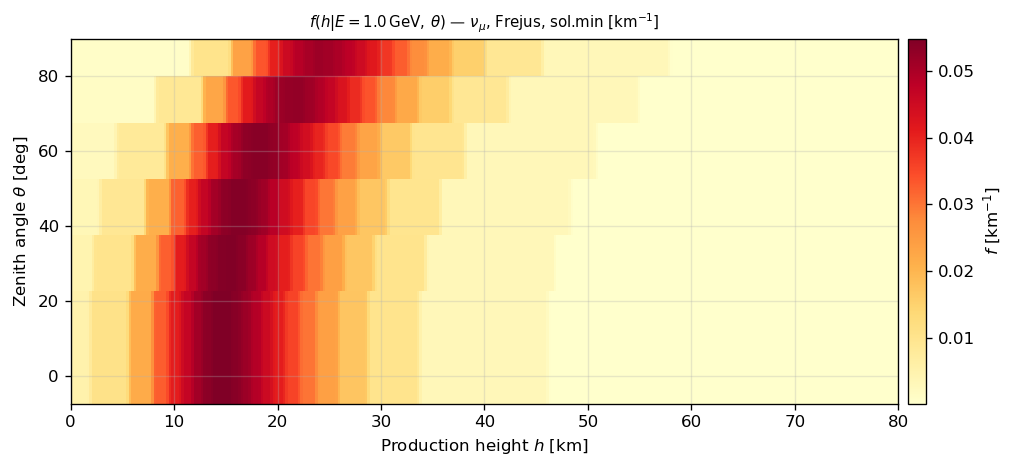

v:\output\analysis\atmosphere\honda_analysis\atm2_fig42_fEh_theta.png


In [12]:
E0 = 1.0   # GeV

f_theta_h = []
for theta in THETA_GRID:
    r  = grid["numu"]["results"][float(theta)]
    E  = r["E_grid_GeV"].cpu().numpy()
    f  = r["f_Eh"].cpu().numpy()
    h  = r["h_grid_km"].cpu().numpy()
    ie = np.argmin(np.abs(E - E0))
    f_theta_h.append(f[ie])

F = np.array(f_theta_h)   # (n_theta, n_h)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.pcolormesh(h, THETA_GRID, F, cmap="YlOrRd", shading="auto")
ax.set_xlabel("Production height $h$ [km]")
ax.set_ylabel(r"Zenith angle $\theta$ [deg]")
ax.set_title(
    rf"$f(h|E={E0}\,{{\rm GeV}},\,\theta)$ — $\nu_\mu$, Frejus, sol.min"
    r" [km$^{-1}$]",
    fontsize=9,
)
ax.set_xlim(0, 80)
plt.colorbar(im, ax=ax, label=r"$f$ [km$^{-1}$]", pad=0.01)
fig.tight_layout()
save_and_show("atm2_fig42_fEh_theta.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 6. Particle and Flavour Comparison

At energies below a few GeV, the atmospheric neutrino flux has a well-known composition dominated by $\nu_\mu$ and $\bar\nu_\mu$ from charged pion and muon decays. The sub-GeV electron neutrinos receive an extra contribution from 3-body kaon decays. Above a few GeV the ratio $\nu_\mu / \nu_e \to 2$ as the muons from pion decays decay before reaching the ground.

### 6.1 $\nu_e$ vs $\nu_\mu$ Spectra

**Expected results:**
- $\Phi(\nu_\mu)$ exceeds $\Phi(\nu_e)$ by a factor $\sim 2$ above 1 GeV.
- Below $\sim 0.3$ GeV the ratio $\Phi(\nu_\mu)/\Phi(\nu_e)$ drops toward 1 because the muons stop before decaying.

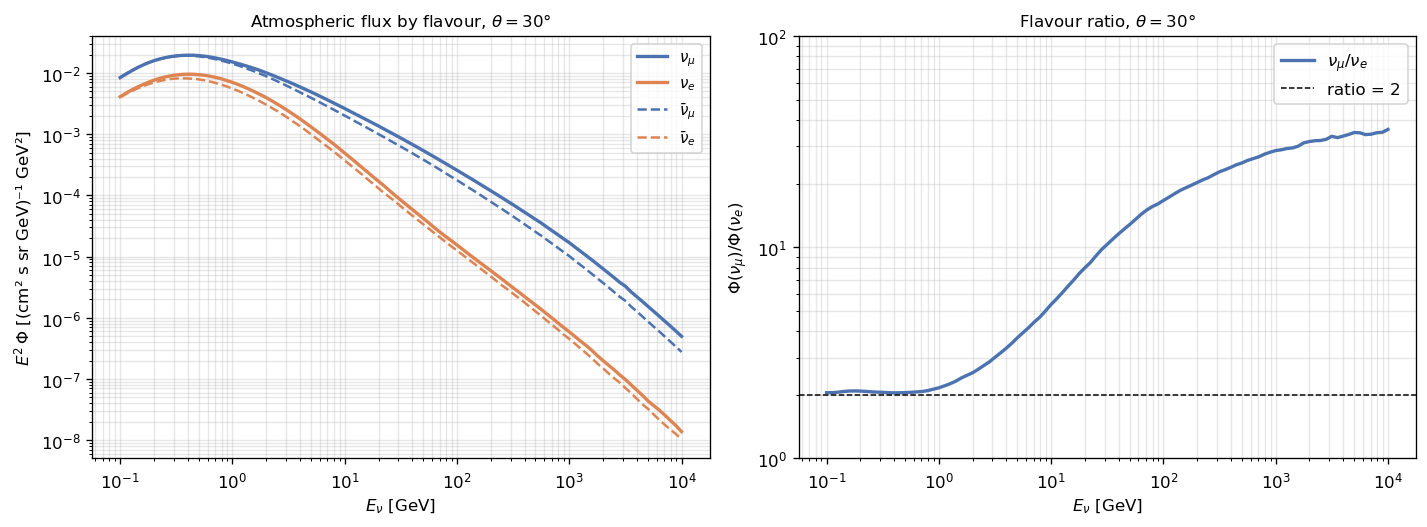

v:\output\analysis\atmosphere\honda_analysis\atm2_fig51_flavour.png


In [13]:
THETA0 = 30.0   # degrees
styles = {
    "numu":    dict(color="#4c72b0", lw=2.0, label=r"$\nu_\mu$"),
    "nue":     dict(color="#dd8452", lw=2.0, label=r"$\nu_e$"),
    "antinumu":dict(color="#4c72b0", lw=1.5, ls="--", label=r"$\bar\nu_\mu$"),
    "antinue": dict(color="#dd8452", lw=1.5, ls="--", label=r"$\bar\nu_e$"),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: all four flavours
ax = axes[0]
for flav, style in styles.items():
    r   = grid[flav]["results"][THETA0]
    E   = r["E_grid_GeV"].cpu().numpy()
    phi = r["phi_E_obs"].cpu().numpy()
    ax.loglog(E, phi * E**2, **style)
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E^2\,\Phi$ [(cm² s sr GeV)⁻¹ GeV²]")
ax.set_title(rf"Atmospheric flux by flavour, $\theta={THETA0:.0f}°$", fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

# Right: nu_mu / nu_e ratio
ax = axes[1]
r_mu = grid["numu"]["results"][THETA0]
r_e  = grid["nue"]["results"][THETA0]
E_mu = r_mu["E_grid_GeV"].cpu().numpy()
phi_mu = r_mu["phi_E_obs"].cpu().numpy()
phi_e  = np.interp(E_mu, r_e["E_grid_GeV"].cpu().numpy(), r_e["phi_E_obs"].cpu().numpy())
ratio  = np.where(phi_e > 0, phi_mu / phi_e, np.nan)
ax.loglog(E_mu, ratio, color="#4c72b0", lw=2, label=r"$\nu_\mu / \nu_e$")
ax.axhline(2.0, color="k", lw=0.9, ls="--", label="ratio = 2")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\Phi(\nu_\mu) / \Phi(\nu_e)$")
ax.set_title(rf"Flavour ratio, $\theta={THETA0:.0f}°$", fontsize=10)
ax.legend()
ax.grid(True, which="both", alpha=0.3)
ax.set_ylim(1e0, 1e2)

fig.tight_layout()
save_and_show("atm2_fig51_flavour.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 6.2 $\nu / \bar\nu$ Ratios

The ratio $\Phi(\nu_\mu) / \Phi(\bar\nu_\mu)$ is driven by the excess of positive pions over negative pions in cosmic-ray proton-dominated showers (the proton excess model). Above a few GeV it stabilises around $\sim 1.1\text{–}1.3$.

**Expected results:** 
- $\nu / \bar\nu > 1$ for both $\mu$ and $e$ flavours; weakly energy-dependent above 1 GeV.

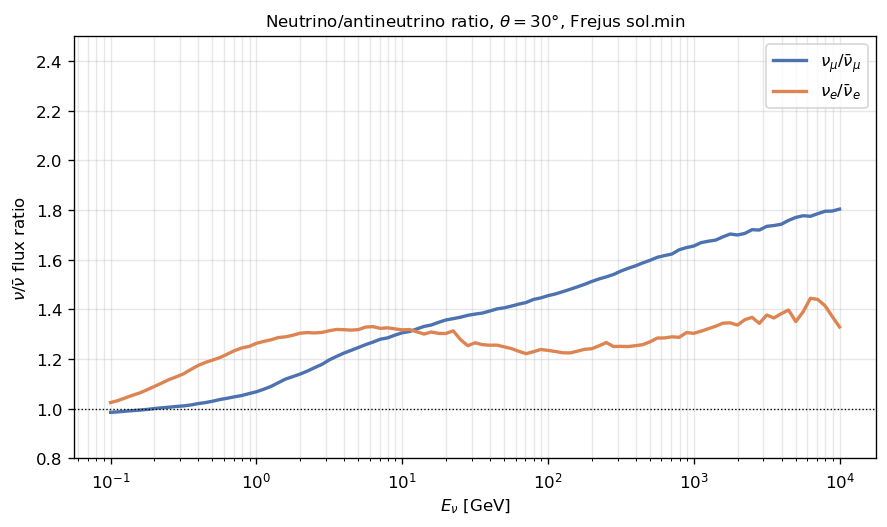

v:\output\analysis\atmosphere\honda_analysis\atm2_fig52_nu_ratio.png


In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

for (flav, aflav, label, col) in [
    ("numu",  "antinumu", r"$\nu_\mu / \bar\nu_\mu$", "#4c72b0"),
    ("nue",   "antinue",  r"$\nu_e / \bar\nu_e$",        "#dd8452"),
]:
    r_nu   = grid[flav]["results"][THETA0]
    r_anu  = grid[aflav]["results"][THETA0]
    E      = r_nu["E_grid_GeV"].cpu().numpy()
    phi_nu = r_nu["phi_E_obs"].cpu().numpy()
    phi_an = np.interp(E, r_anu["E_grid_GeV"].cpu().numpy(), r_anu["phi_E_obs"].cpu().numpy())
    ratio  = np.where(phi_an > 0, phi_nu / phi_an, np.nan)
    ax.semilogx(E, ratio, color=col, lw=2, label=label)

ax.axhline(1.0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\nu / \bar\nu$ flux ratio")
ax.set_title(rf"Neutrino/antineutrino ratio, $\theta={THETA0:.0f}°$, Frejus sol.min", fontsize=10)
ax.legend()
ax.grid(True, which="both", alpha=0.3)
ax.set_ylim(0.8, 2.5)
fig.tight_layout()
save_and_show("atm2_fig52_nu_ratio.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 7. Solar and Mountain Corrections

Honda provides two solar-activity variants (solar minimum and solar maximum) and a mountain-corrected table for sites with a significant nearby mountain that shadows part of the solid angle.

- **Solar modulation**: the lower-energy primary cosmic-ray flux ($E_p \lesssim 10$ GeV) is suppressed during solar maximum by the heliospheric magnetic field. This reduces the sub-GeV atmospheric neutrino flux by up to $\sim 10\%$.
- **Mountain effect**: a nearby mountain blocks downward-going cosmic rays in certain azimuth/zenith ranges, reducing the neutrino flux in the corresponding solid-angle region. Relevant for Frejus (Grandes Jorasses ridge) and Gran Sasso.

### 7.1 Solar Min vs Solar Max

**Expected results:** 
- Solar-maximum flux is lower than solar-minimum by up to $\sim 10\%$ at 0.1–0.3 GeV, with negligible difference above $\sim 5$ GeV.

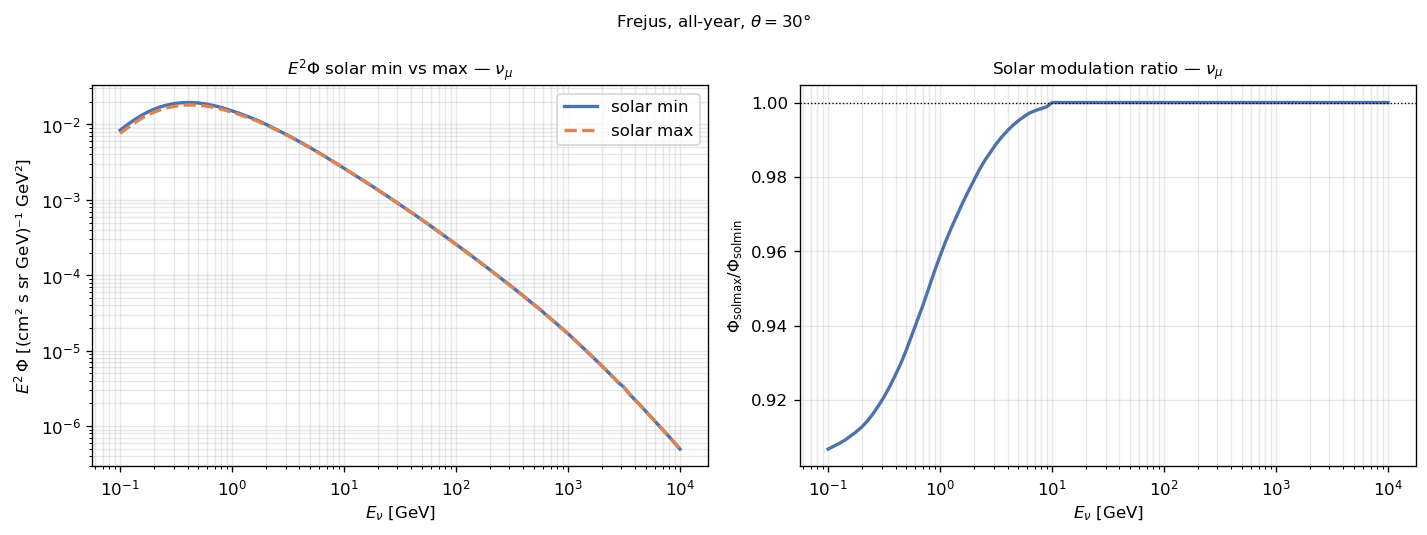

v:\output\analysis\atmosphere\honda_analysis\atm2_fig61_solar.png


In [15]:
THETA0 = 30.0   # reference angle (degrees) matching SS 5-6

sel_max = HondaTableSelection(
    site_code    = "frj",
    season_code  = "ally",
    solar        = "solmax",
    mountain     = False,
    angular_mode = "azimuth-averaged",
)

r_min = generate_flux_for_particle_angle("numu", theta_deg=THETA0, selection=sel,     save=False, honda_data_dir = HONDA_DIR,)
r_max = generate_flux_for_particle_angle("numu", theta_deg=THETA0, selection=sel_max, save=False, honda_data_dir = HONDA_DIR,)

E_min   = r_min["E_grid_GeV"].cpu().numpy()
phi_min = r_min["phi_E_obs"].cpu().numpy()
phi_max = np.interp(E_min, r_max["E_grid_GeV"].cpu().numpy(), r_max["phi_E_obs"].cpu().numpy())
ratio   = np.where(phi_min > 0, phi_max / phi_min, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(E_min, phi_min * E_min**2, color="#4c72b0", lw=2, label="solar min")
ax.loglog(E_min, phi_max * E_min**2, color="#dd8452", lw=2, ls="--", label="solar max")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$E^2\,\Phi$ [(cm² s sr GeV)⁻¹ GeV²]")
ax.set_title(r"$E^2\Phi$ solar min vs max — $\nu_\mu$", fontsize=10)
ax.legend()
ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
ax.semilogx(E_min, ratio, color="#4c72b0", lw=2)
ax.axhline(1.0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\Phi_{\rm solmax} / \Phi_{\rm solmin}$")
ax.set_title(r"Solar modulation ratio — $\nu_\mu$", fontsize=10)
ax.grid(True, which="both", alpha=0.3)

fig.suptitle(rf"Frejus, all-year, $\theta={THETA0:.0f}°$", fontsize=10)
fig.tight_layout()
save_and_show("atm2_fig61_solar.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 7.2 Mountain Correction

For sites with a nearby mountain (e.g. Frejus, with the Grandes Jorasses ridge), a fraction of the downward-going sky is shielded. This reduces the neutrino flux in the affected solid-angle sector. The azimuth-averaged tables fold this correction over all azimuth bins.

**Expected results:**
- The mountain correction is $\lesssim 5\%$ for the azimuth-averaged flux at Frejus.
- It is most visible at large zenith angles ($\theta \sim 60\text{–}80°$) where the mountain covers a larger fraction of the solid angle.

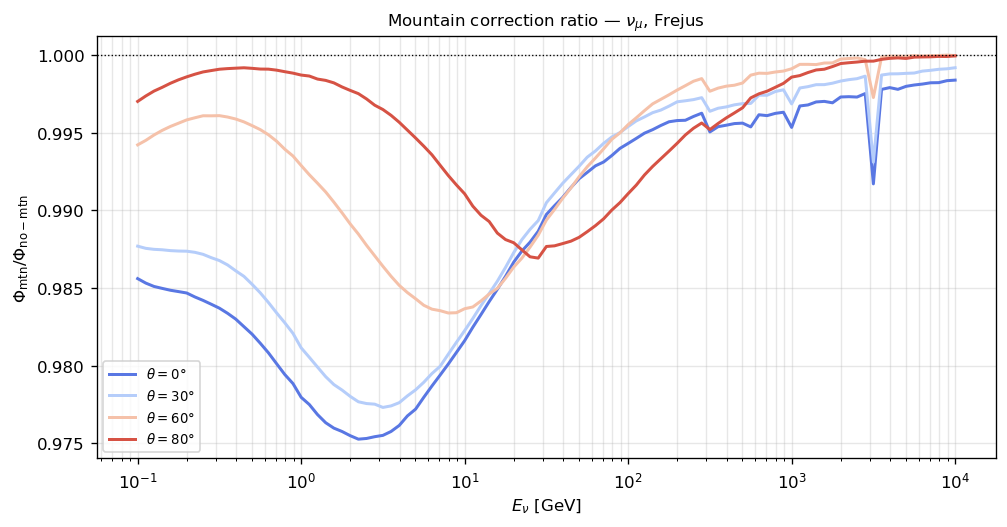

v:\output\analysis\atmosphere\honda_analysis\atm2_fig62_mountain.png


In [16]:
try:
    sel_mtn = HondaTableSelection(
        site_code    = "frj",
        season_code  = "ally",
        solar        = "solmin",
        mountain     = True,
        angular_mode = "azimuth-averaged",
    )
    _ = choose_flux_file(honda_dir, sel_mtn)   # will raise if not found
    has_mountain = True
except FileNotFoundError:
    has_mountain = False
    print("Mountain-corrected table not found for this site; skipping comparison.")

if has_mountain:
    theta_vals_mtn = np.array([0., 30., 60., 80.])
    phi_nomt  = {}
    phi_mt    = {}
    for th in theta_vals_mtn:
        r0 = generate_flux_for_particle_angle("numu", theta_deg=th, selection=sel,     save=False, honda_data_dir = HONDA_DIR,)
        rm = generate_flux_for_particle_angle("numu", theta_deg=th, selection=sel_mtn, save=False, honda_data_dir = HONDA_DIR,)
        E  = r0["E_grid_GeV"].cpu().numpy()
        phi_nomt[th] = r0["phi_E_obs"].cpu().numpy()
        phi_mt[th]   = np.interp(E, rm["E_grid_GeV"].cpu().numpy(), rm["phi_E_obs"].cpu().numpy())

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    colors_mtn = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(theta_vals_mtn)))
    for th, col in zip(theta_vals_mtn, colors_mtn):
        ratio = np.where(phi_nomt[th] > 0, phi_mt[th] / phi_nomt[th], np.nan)
        ax.semilogx(E, ratio, color=col, lw=1.8, label=rf"$\theta={th:.0f}°$")
    ax.axhline(1.0, color="k", lw=0.8, ls=":")
    ax.set_xlabel(r"$E_\nu$ [GeV]")
    ax.set_ylabel(r"$\Phi_{\rm mtn} / \Phi_{\rm no-mtn}$")
    ax.set_title(r"Mountain correction ratio — $\nu_\mu$, Frejus", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    save_and_show("atm2_fig62_mountain.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 8. Flux Normalization Check

The height density $f(h|E,\theta)$ is normalized so that $\int_0^\infty f(h|E,\theta)\,dh = 1$ for each $(E, \theta)$ bin. Integrating the height-differential flux $\Phi(E,h)$ over $h$ must recover the original Honda integrated flux $\Phi(E; X_{\rm obs})$:

$$\Phi(E; X_{\rm obs}) = \int_0^{h_{\rm max}} \Phi(E,h)\,dh$$

This serves as a basic consistency check of the height-distribution reconstruction.

### 8.1 Integrate $\Phi(E,h)$ over Height

**Expected results:** 
- The reconstructed $\int \Phi(E,h)\,dh$ agrees with $\Phi(E; X_{\rm obs})$ to better than 0.1% for all energies and angles (machine-precision limit of the numerical differentiation of the CDF).

In [17]:
print(f"{'Particle':10s}  {'theta':>7s}  {'max|1 - integral|':>18s}  {'mean|1 - integral|':>20s}")
print("-" * 62)

for flav in ["numu", "nue"]:
    for theta in [0., 30., 60., 85.]:
        r    = grid[flav]["results"][theta]
        E    = r["E_grid_GeV"].cpu().numpy()
        h    = r["h_grid_km"].cpu().numpy()
        phi  = r["phi_E_obs"].cpu().numpy()
        f    = r["f_Eh"].cpu().numpy()
        phi_h = r["phi_Eh"].cpu().numpy()   # (nE, nh)

        # Check 1: normalization of f(h|E)
        norm_f = np.trapz(f, h, axis=1)   # should be 1 for all E

        # Check 2: integral of phi_Eh over h should recover phi_E
        phi_recov = np.trapz(phi_h, h, axis=1)
        with np.errstate(invalid="ignore", divide="ignore"):
            rel_err = np.where(phi > 0, np.abs(phi_recov / phi - 1.0), np.nan)

        print(f"{flav:10s}  {theta:6.0f}°  "
              f"{np.nanmax(rel_err):>18.2e}  {np.nanmean(rel_err):>20.2e}")

print()
print("Normalization of f(h|E) (should be 1):")
r0     = grid["numu"]["results"][30.0]
f0     = r0["f_Eh"].cpu().numpy()
h0     = r0["h_grid_km"].cpu().numpy()
norms  = np.trapz(f0, h0, axis=1)
print(f"  min = {norms.min():.6f}   max = {norms.max():.6f}"
      f"   mean = {norms.mean():.6f}")

Particle      theta   max|1 - integral|    mean|1 - integral|
--------------------------------------------------------------
numu             0°            4.44e-16              1.22e-16
numu            30°            3.33e-16              7.58e-17
numu            60°            2.22e-16              9.67e-17
numu            85°            4.44e-16              1.28e-16
nue              0°            4.44e-16              1.09e-16
nue             30°            4.44e-16              1.11e-16
nue             60°            3.33e-16              1.13e-16
nue             85°            6.66e-16              1.08e-16

Normalization of f(h|E) (should be 1):
  min = 1.000000   max = 1.000000   mean = 1.000000


## 9. Summary

| Step | Function / class | Output |
|------|-----------------|--------|
| Locate data | `find_honda_data_dir()` | Path to `.d.gz` directory |
| Select variant | `HondaTableSelection(site_code, season_code, solar, mountain, angular_mode)` | Frozen config dataclass |
| Single angle | `generate_flux_for_particle_angle(particle, theta_deg=..., selection=sel, save=False)` | `E_grid_GeV`, `h_grid_km`, `phi_E_obs`, `f_Eh`, `phi_Eh` |
| Full grid | `generate_flux_for_particles_angle_grid(particles, theta_grid_deg=..., selection=sel, save=False)` | Dict keyed by flavour → Dict keyed by θ |
| Native cosθ bins | `honda_cosz_centers()` | 20-element array from 0.95 to −0.95 |

**Key physics findings:**
- Production height PDF $f(h|E,\theta)$ peaks between 10–25 km; higher energy and more horizontal neutrinos are produced lower in the atmosphere.
- The $\nu_\mu / \nu_e$ ratio approaches 2 above $\sim 1$ GeV.
- Solar modulation reduces the flux by up to $\sim 10\%$ below $\sim 0.5$ GeV.
- The normalization check confirms $\int f(h|E)\,dh = 1$ to better than $10^{-4}$ relative error.

**Next step:** Use `generate_flux_for_particles_angle_grid(..., save=True, output_config=...)` to write the height-differential flux files needed by the tpeanuts atmosphere propagation pipeline.

In [18]:
print("=" * 60)
print("Atmosphere Analysis 2 — Summary")
print("=" * 60)
print(f"  Honda data dir  : {honda_dir}")
print(f"  Site / season   : {sel.site_code} / {sel.season_code}")
print(f"  Solar           : {sel.solar}")
print(f"  Angular mode    : {sel.angular_mode}")
print(f"  Energy range    : {E_GeV[0]:.3g} -- {E_GeV[-1]:.3g} GeV ({E_GeV.size} pts)")
print(f"  Height range    : {h_km[0]:.0f} -- {h_km[-1]:.0f} km ({h_km.size} pts)")
print(f"  Particles shown : {PARTICLES}")
print(f"  Theta grid      : {list(THETA_GRID)}")
print(f"  Output dir      : {OUTPUT_DIR}")

Atmosphere Analysis 2 — Summary
  Honda data dir  : v:\output\external\honda
  Site / season   : frj / ally
  Solar           : solmin
  Angular mode    : azimuth-averaged
  Energy range    : 0.1 -- 1e+04 GeV (101 pts)
  Height range    : 0 -- 120 km (501 pts)
  Particles shown : ['numu', 'nue', 'antinumu', 'antinue']
  Theta grid      : [0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 85.0]
  Output dir      : v:\output\analysis\atmosphere\honda_analysis
